# Evaluation Workbench (Canonical)
Notebook-first evaluation for Actual SF / Actual All / POL + arbitrary MMv4 run folders.

This notebook reports **raw metric values only** (no thresholds, no PASS/FAIL) and supports model-to-model visual comparison.

## Compact Metric Guide
If your viewer does not render math, use the plain-text formula line above each equation.

- **Location-count distribution distance (JSD)**: lower is better.  
  Plain text: `JSD(P,Q) = sqrt(0.5*KL(P||M) + 0.5*KL(Q||M)), M = 0.5*(P+Q)`

$$
\mathrm{JSD}(P,Q)=\sqrt{\frac{1}{2}\mathrm{KL}(P\|M)+\frac{1}{2}\mathrm{KL}(Q\|M)},\quad M=\frac{P+Q}{2}
$$

- **Transition-matrix distances (L1 / mean-abs / max-abs / L2)**: lower is better.  
  Plain text: `L1, L2, max(|Delta|), mean(|Delta|) between model and actual transition matrices`

$$
\lVert T_{model}-T_{actual}\rVert_1,\quad \lVert T_{model}-T_{actual}\rVert_2,\quad \max\!\left|\Delta\right|,\quad \mathrm{mean}\!\left|\Delta\right|
$$

- **Chain overlap + chain JSD**: overlap higher is better, chain JSD lower is better.

- **Temporal start-time error (MAE/RMSE)** for mandatory activities: lower is better.  
  Plain text: `MAE = (1/n) * sum |t_hat_i - t_i|, RMSE = sqrt((1/n) * sum (t_hat_i - t_i)^2)`

$$
\mathrm{MAE}=\frac{1}{n}\sum_i\left|\hat t_i-t_i\right|,\quad \mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_i(\hat t_i-t_i)^2}
$$

- **Dwell-time fit and Trips/day fit**: closer to Actual SF is better.

## What We Inspect
- **Pattern level**: location-count and travel-time distributions.
- **Trip level**: transition matrices + destination probability profile.
- **Chain level**: full-day sequence realism (weighted + percentage overlaps, chain JSD).
- **Temporal/dwell/trips diagnostics**: timing and duration behavior.

POL is included where comparable; non-comparable metrics are marked non-evaluable in tables.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
SIM_RUNS: dict[str, str] = {
    "OSS_20B": "simulation_outputs/SF_1k_oss_20b",
    "OSS_120B": "simulation_outputs/SF_1k_oss_120b",
    # "OSS-20B-FT-SF-1EPOCH": "simulation_outputs/SF_1k_oss_20b_lora-sf-1epoch",
    "OSS-20B-FT-SF": "simulation_outputs/SF_1k_oss_20b_lora-sf-5epoch",
    # "OSS-20B-FT-SF-10EPOCH": "simulation_outputs/SF_1k_oss_20b_lora-sf-10epoch",
    # "OSS-20B-FT-1EPOCH": "simulation_outputs/SF_1k_oss_20b_lora-1epoch",
    "OSS-20B-FT-US": "simulation_outputs/SF_1k_oss_20b_lora-5epoch",
    # "OSS-20B-FT-10EPOCH": "simulation_outputs/SF_1k_oss_20b_lora-10epoch",
}


SIM_RUN_INPUT_FOLDERS: dict[str, str] = {
    "OSS_20B": "Inputs/SF_agents_1K",
    "OSS_120B": "Inputs/SF_agents_1K",
    # "OSS-20B-FT-SF-1EPOCH": "Inputs/SF_agents_1K",
    "OSS-20B-FT-SF": "Inputs/SF_agents_1K",
    # "OSS-20B-FT-SF-10EPOCH": "Inputs/SF_agents_1K",
    # "OSS-20B-FT-1EPOCH": "Inputs/SF_agents_1K",
    "OSS-20B-FT-US": "Inputs/SF_agents_1K",
    # "OSS-20B-FT-10EPOCH": "Inputs/SF_agents_1K",
}

POL_FILE = "dataset/simulation.csv"
SEED = 42
DAY_SELECTOR = "random"  # all|first|last|random|second|sixth|fourth
TARGET_TAXONOMY = "legacy6"
TEMPORAL_ACTIVITY_CODES = (2, 4)


## Notebook Usage
1. Edit `SIM_RUNS` in the next code cell.
2. Run all cells top-to-bottom.
3. Compare wide metric tables first, then visual diagnostics.

This notebook is the canonical evaluation entrypoint.

In [3]:
%matplotlib inline
import matplotlib as mpl
print('Matplotlib backend:', mpl.get_backend())



Matplotlib backend: inline


In [4]:
from pathlib import Path
import sys
analysis_dir = Path.cwd() / "analysis"
if analysis_dir.exists() and str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from constants import SIM_LOC_TYPES, LEGACY6_STATE_CODES
from utils import (
    get_transient_prob,
    load_actual_reference_frames,
    load_pol_simulation_normalized,
    load_simulation_run_dict,
    filter_eval_frame_by_cohort,
    build_cohort_model_frames,
)
from evals import (
    build_notebook_evaluation_tables,
    plot_chord_diagrams,
    plot_location_count_percentage_grid,
    plot_travel_time_pair_grid,
    trip_level,
    plot_location_count_percentage_grid_better,
    plot_chord_diagrams_better
)


In [5]:
STATE_CODES = LEGACY6_STATE_CODES
LOC_TYPE_LABELS = SIM_LOC_TYPES
VALID_DAY_SELECTORS = {"all", "first", "second", "sixth", "last", "random", "third", "fourth"}

if DAY_SELECTOR not in VALID_DAY_SELECTORS:
    raise ValueError(
        f"Unsupported DAY_SELECTOR '{DAY_SELECTOR}'. "
        f"Choose one of: {sorted(VALID_DAY_SELECTORS)}"
    )

refs = load_actual_reference_frames(target_taxonomy=TARGET_TAXONOMY)
actual_sf = refs["actual_sf"]
actual_all = refs["actual_all"]
pol_df = load_pol_simulation_normalized(POL_FILE, seed=SEED, target_taxonomy=TARGET_TAXONOMY)
sim_frames = load_simulation_run_dict(
    SIM_RUNS,
    day_selector=DAY_SELECTOR,
    seed=SEED,
    run_input_folders=SIM_RUN_INPUT_FOLDERS,
    target_taxonomy=TARGET_TAXONOMY,
)
model_frames = {"POL": pol_df, **sim_frames}

print(f"DAY_SELECTOR: {DAY_SELECTOR}")
print(f"Actual SF rows: {len(actual_sf)}")
print(f"Actual All rows: {len(actual_all)}")
for name, df in model_frames.items():
    agents = int(df["agent_id"].nunique()) if "agent_id" in df.columns else len(df)
    unique_dates = int(df["date"].dropna().nunique()) if "date" in df.columns else 0
    max_days_per_agent = None
    if {"agent_id", "date"}.issubset(df.columns):
        day_counts = df.groupby("agent_id")["date"].nunique(dropna=True)
        if len(day_counts):
            max_days_per_agent = int(day_counts.max())
    typed = (
        int(pd.to_numeric(df["agent_type"], errors="coerce").notna().sum())
        if "agent_type" in df.columns else 0
    )
    print(
        f"{name}: rows={len(df)} agents={agents} "
        f"unique_dates={unique_dates} max_days_per_agent={max_days_per_agent} "
        f"typed_rows={typed}"
    )


Normalizing actual dataframe with columns: ['age', 'agent_type', 'combined_time', 'date', 'graph', 'hhid', 'loc_type', 'location', 'nhts_prmact_code', 'nhts_schtyp_code', 'nhts_worker_code', 'person', 'person_class', 'sex', 'sex_orig', 'survey_date', 'travel_time', 'user_id']
Normalizing actual dataframe with columns: ['age', 'agent_type', 'graph', 'hhid', 'loc_type', 'location', 'nhts_prmact_code', 'nhts_schtyp_code', 'nhts_worker_code', 'person', 'person_class', 'sex', 'sex_orig', 'survey_date', 'travel_time']
Normalizing pol dataframe with columns: ['agent_id', 'date', 'loc_type', 'loc_type_cat', 'location']
[cohort-join] OSS_20B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS_120B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'a

In [6]:
tables = build_notebook_evaluation_tables(
    actual_sf_df=actual_sf,
    actual_all_df=actual_all,
    model_frames=model_frames,
    temporal_activity_codes=TEMPORAL_ACTIVITY_CODES,
    state_codes=STATE_CODES,
    loc_type_labels=LOC_TYPE_LABELS,
)

def metric_model_table(section_df):
    wide = (
        section_df
        .pivot_table(index=["metric", "unit"], columns="model", values="value", aggfunc="first")
        .sort_index()
    )
    return wide

for section in ["pattern", "trip", "chain", "temporal_dwell_trips"]:
    print("\n" + "=" * 100)
    print(section.upper())
    wide = metric_model_table(tables[section])
    display(wide)
    na_rows = tables[section].loc[~tables[section]["evaluable"], ["metric", "model", "reason"]]
    if not na_rows.empty:
        print("Non-evaluable rows:")
        display(na_rows.sort_values(["metric", "model"]).reset_index(drop=True))



PATTERN


,model,OSS-20B-FT-SF,OSS-20B-FT-US,OSS_120B,OSS_20B,POL
metric,unit,,,,,
loc_type_distribution_l1_vs_actual,probability_mass,0.081910,0.093870,0.241880,0.331027,0.336786
location_count_mean,stops/day,5.210000,4.860000,5.218000,5.657000,4.263754
location_count_mean_abs_error_vs_actual,stops/day,0.162734,0.512734,0.154734,0.284266,1.108980
location_count_median,stops/day,5.000000,5.000000,5.000000,5.000000,4.000000
travel_time_mean_abs_error_hours_vs_actual,hours/day,0.601443,0.717693,0.598193,0.462026,NaN
travel_time_mean_hours,hours/day,1.139750,1.023500,1.143000,1.279167,NaN


Non-evaluable rows:


,metric,model,reason
0,travel_time_mean_abs_error_hours_vs_actual,POL,Missing actual or model travel-time means.
1,travel_time_mean_hours,POL,No travel_time column with valid values.



TRIP


...

,model,OSS-20B-FT-SF,OSS-20B-FT-US,OSS_120B,OSS_20B,POL
metric,unit,,,,,
chain_jsd_vs_actual_sf,jsd,0.459569,0.445816,0.606021,0.583944,0.625058
chain_weight_overlap_actual_sf_generated,percent,43.738465,44.182741,23.281301,28.230320,26.573045
pct_actual_sf_chains_in_generated,percent,11.627907,12.121212,9.090909,10.077519,7.188161
pct_generated_chains_in_actual_all,percent,69.230769,72.790698,84.046693,69.059406,75.617284
pct_generated_chains_in_actual_sf,percent,37.330317,40.000000,50.194553,35.396040,31.481481
weight_actual_sf_chains_in_generated,percent,52.917805,54.680904,46.337224,46.213062,36.602930
weight_generated_chains_in_actual_all,percent,82.700000,84.400000,93.700000,86.700000,96.052759
weight_generated_chains_in_actual_sf,percent,66.600000,68.600000,77.200000,67.700000,84.975705



TEMPORAL_DWELL_TRIPS


,model,OSS-20B-FT-SF,OSS-20B-FT-US,OSS_120B,OSS_20B,POL
metric,unit,,,,,
dwell_wasserstein_errands_minutes_vs_actual,minutes,17.638597,55.019686,59.885809,39.169109,NaN
dwell_wasserstein_home_minutes_vs_actual,minutes,55.183083,47.980512,63.294752,50.886821,NaN
dwell_wasserstein_mean_minutes_vs_actual,minutes,45.982346,63.855583,87.750263,88.856922,NaN
dwell_wasserstein_recreation_minutes_vs_actual,minutes,17.484398,25.261001,59.275685,66.912185,NaN
dwell_wasserstein_restaurant_minutes_vs_actual,minutes,9.337927,9.639584,21.446721,17.671505,NaN
dwell_wasserstein_school_minutes_vs_actual,minutes,97.286765,144.539477,206.988510,177.031608,NaN
dwell_wasserstein_work_minutes_vs_actual,minutes,78.963307,100.693240,115.610104,181.470303,NaN
school_weekday_start_inter_std_abs_error_minutes_vs_actual,minutes,111.455383,121.679256,7.693814,17.695032,NaN
school_weekday_start_inter_std_minutes,minutes,261.599781,271.823654,157.838212,132.449366,NaN


Non-evaluable rows:


,metric,model,reason
0,dwell_wasserstein_errands_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
1,dwell_wasserstein_home_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
2,dwell_wasserstein_mean_minutes_vs_actual,POL,No evaluable dwell activity distances.
3,dwell_wasserstein_recreation_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
4,dwell_wasserstein_restaurant_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
5,dwell_wasserstein_school_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
6,dwell_wasserstein_work_minutes_vs_actual,POL,Missing comparable dwell samples for model or ...
7,school_weekday_start_inter_std_abs_error_minut...,POL,Missing model or actual inter-person start-tim...
8,school_weekday_start_inter_std_minutes,POL,No combined_time data available.
9,school_weekday_start_intra_std_abs_error_minut...,OSS-20B-FT-SF,Missing model or actual intra-person start-tim...


In [7]:
combined_table = pd.concat(
    [
        t.assign(section=name)
        for name, t in tables.items()
    ],
    ignore_index=True,
)

combined_wide = (
    combined_table
    .pivot_table(index=["section", "metric", "unit"], columns="model", values="value", aggfunc="first")
    .sort_index()
)
display(combined_wide)


model                                                                                     OSS-20B-FT-SF  \
section              metric                                             unit                              
chain                chain_jsd_vs_actual_sf                             jsd                    0.459569   
                     chain_weight_overlap_actual_sf_generated           percent               43.738465   
                     pct_actual_sf_chains_in_generated                  percent               11.627907   
                     pct_generated_chains_in_actual_all                 percent               69.230769   
                     pct_generated_chains_in_actual_sf                  percent               37.330317   
                     weight_actual_sf_chains_in_generated               percent               52.917805   
                     weight_generated_chains_in_actual_all              percent               82.700000   
                     weight_generated_chains_in_actual_sf               percent               66.600000   
pattern              loc_type_distribution_l1_vs_actual                 probability_mass       0.081910   
                     location_count_mean                                stops/day              5.210000   
                     location_count_mean_abs_error_vs_actual            stops/day              0.162734   
                     location_count_median                              stops/day              5.000000   
                     travel_time_mean_abs_error_hours_vs_actual         hours/day              0.601443   
                     travel_time_mean_hours                             hours/day              1.139750   
temporal_dwell_trips dwell_wasserstein_errands_minutes_vs_actual        minutes               17.638597   
                     dwell_wasserstein_home_minutes_vs_actual           minutes               55.183083   
                     dwell_wasserstein_mean_minutes_vs_actual           minutes               45.982346   
                     dwell_wasserstein_recreation_minutes_vs_actual     minutes               17.484398   
                     dwell_wasserstein_restaurant_minutes_vs_actual     minutes                9.337927   
                     dwell_wasserstein_school_minutes_vs_actual         minutes               97.286765   
                     dwell_wasserstein_work_minutes_vs_actual           minutes               78.963307   
                     school_weekday_start_inter_std_abs_error_minute... minutes              111.455383   
                     school_weekday_start_inter_std_minutes             minutes              261.599781   
                     school_weekday_start_samples                       samples              101.000000   
                     trips_per_person_day_jsd_vs_actual                 jsd                    0.023508   
                     trips_per_person_day_mean                          trips/day              4.210000   
                     trips_per_person_day_mean_abs_error_vs_actual      trips/day              0.162734   
                     trips_per_person_day_wasserstein_vs_actual         trips                  0.216384   
                     work_weekday_start_inter_std_abs_error_minutes_... minutes              130.103326   
                     work_weekday_start_inter_std_minutes               minutes              292.449448   
                     work_weekday_start_samples                         samples              302.000000   
trip                 destination_probability_l1_vs_actual               probability_mass       0.091456   
                     transition_matrix_l2_diff_vs_actual                norm                   0.084331   
                     transition_matrix_max_abs_diff_vs_actual           probability            0.061142   
                     transition_matrix_mean_abs_diff_vs_actual          probability            0.008324   

model                                   

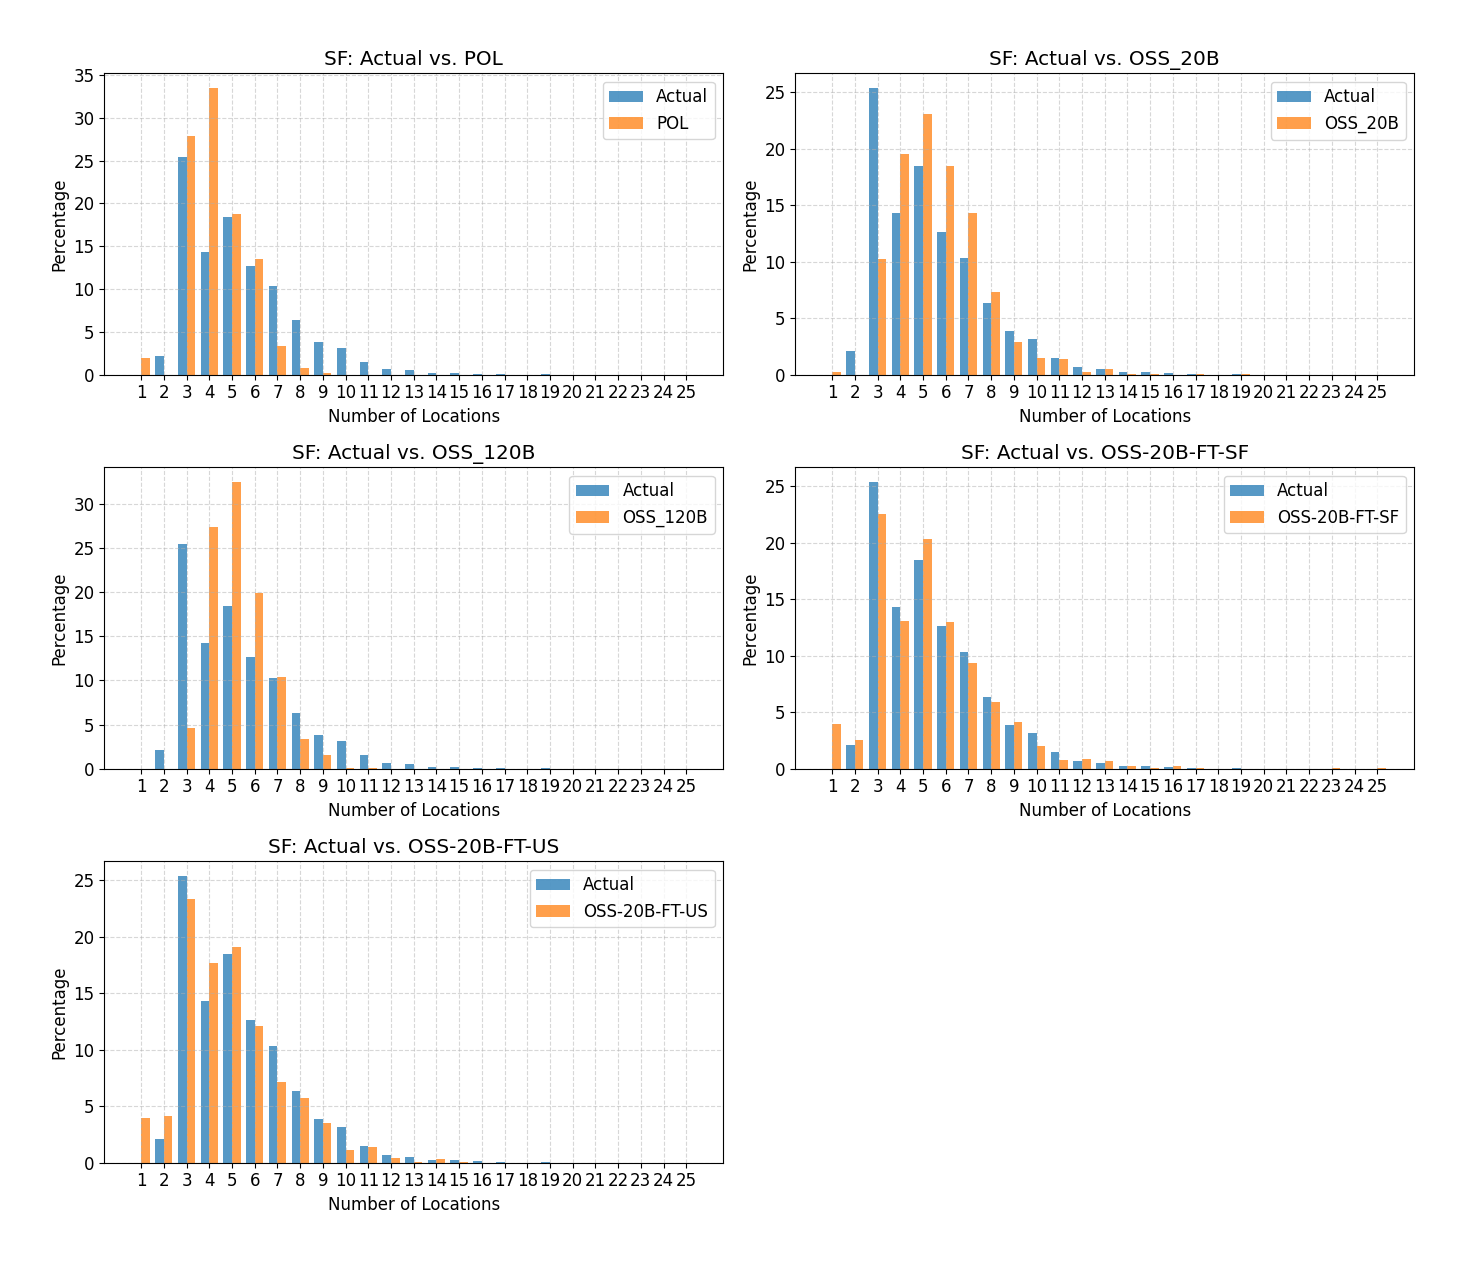

In [8]:
# Pattern-level location-count comparison (parity with legacy main notebook).
actual_loc_counts = actual_sf['location'].dropna().tolist()
model_loc_counts = {
    name: df['location'].dropna().tolist()
    for name, df in model_frames.items()
    # if name != "POL"
}
plot_location_count_percentage_grid(
    actual_counts=actual_loc_counts,
    model_counts=model_loc_counts,
    title_prefix='SF',
    font_size=12,
)


In [9]:
print(sum(actual_loc_counts) / len(actual_loc_counts))
for k,v in model_loc_counts.items():
    print(k, sum(v)/len(v)) 

5.372734045194934
POL 4.263753766095778
OSS_20B 5.657
OSS_120B 5.218
OSS-20B-FT-SF 5.21
OSS-20B-FT-US 4.86


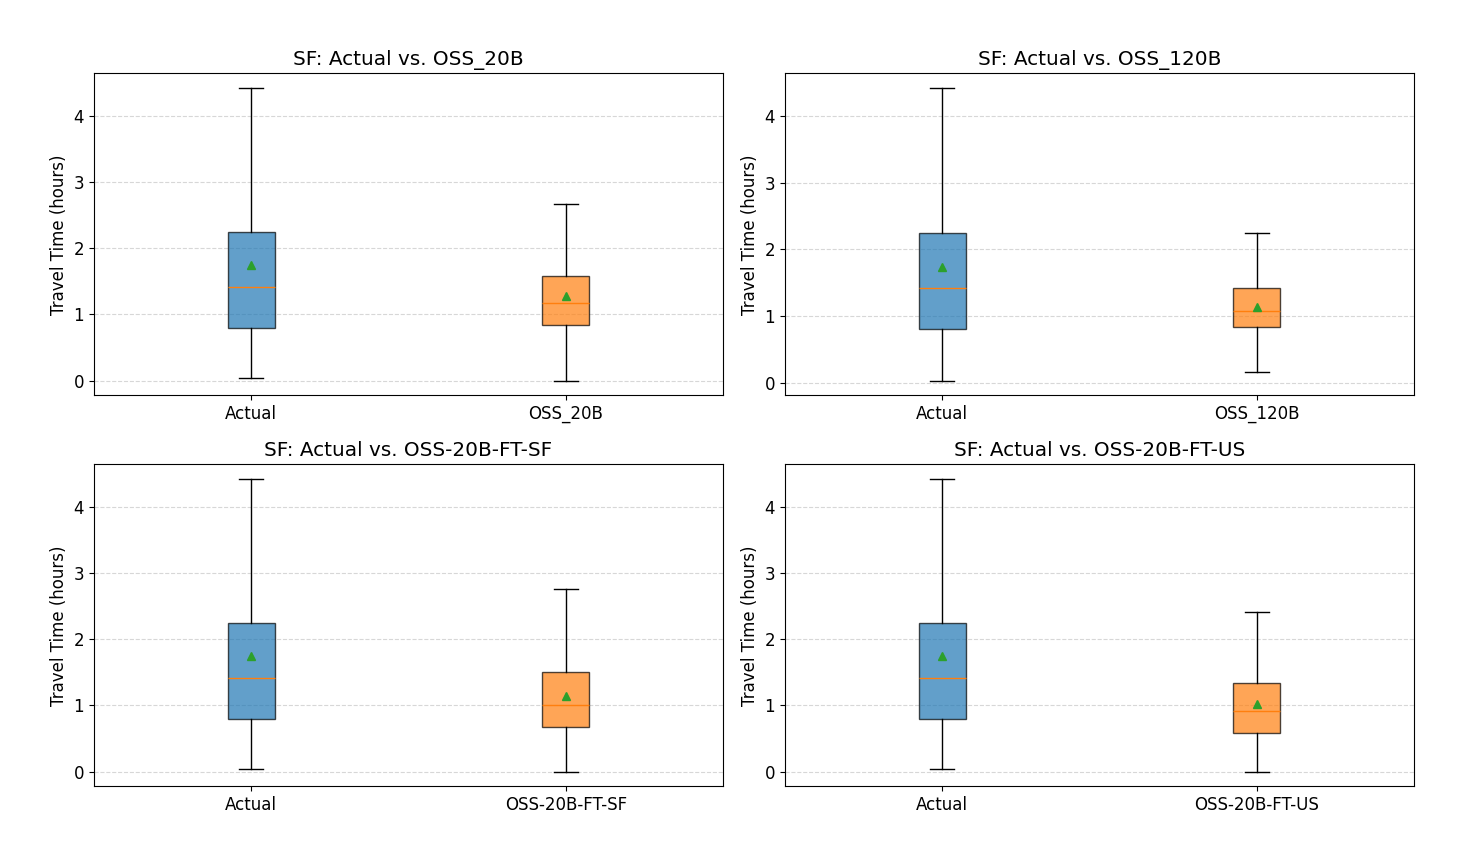

In [10]:
# Pattern-level travel-time comparison (Actual vs models with travel_time only).
actual_travel = actual_sf['travel_time'].dropna().tolist()
model_travel = {}
for name, df in model_frames.items():
    vals = df['travel_time'].dropna().tolist()
    if len(vals) > 0:
        model_travel[name] = vals

plot_travel_time_pair_grid(
    actual_travel_seconds=actual_travel,
    model_travel_seconds=model_travel,
    title_prefix='SF',
    font_size=12,
)


In [11]:
# Chain summary (percent + weighted), parity with legacy main notebook.
chain_focus = [
    'chain_jsd_vs_actual_sf',
    'pct_generated_chains_in_actual_sf',
    'weight_generated_chains_in_actual_sf',
    'pct_generated_chains_in_actual_all',
    'weight_generated_chains_in_actual_all',
    'pct_actual_sf_chains_in_generated',
    'weight_actual_sf_chains_in_generated',
    'chain_weight_overlap_actual_sf_generated',
]
chain_summary = tables["chain"][tables["chain"]["metric"].isin(chain_focus)].copy()
chain_wide = (
    chain_summary
    .pivot_table(index=["metric", "unit"], columns="model", values="value", aggfunc="first")
    .sort_index()
)
display(chain_wide)


,model,OSS-20B-FT-SF,OSS-20B-FT-US,OSS_120B,OSS_20B,POL
metric,unit,,,,,
chain_jsd_vs_actual_sf,jsd,0.459569,0.445816,0.606021,0.583944,0.625058
chain_weight_overlap_actual_sf_generated,percent,43.738465,44.182741,23.281301,28.230320,26.573045
pct_actual_sf_chains_in_generated,percent,11.627907,12.121212,9.090909,10.077519,7.188161
pct_generated_chains_in_actual_all,percent,69.230769,72.790698,84.046693,69.059406,75.617284
pct_generated_chains_in_actual_sf,percent,37.330317,40.000000,50.194553,35.396040,31.481481
weight_actual_sf_chains_in_generated,percent,52.917805,54.680904,46.337224,46.213062,36.602930
weight_generated_chains_in_actual_all,percent,82.700000,84.400000,93.700000,86.700000,96.052759
weight_generated_chains_in_actual_sf,percent,66.600000,68.600000,77.200000,67.700000,84.975705


{'Actual': 0.0,
 'OSS-20B-FT-SF': 0.08433069807002293,
 'OSS-20B-FT-US': 0.07759462919118063,
 'OSS_120B': 0.14706036065530648,
 'OSS_20B': 0.17911834116050654,
 'POL': 0.2208203662439655}


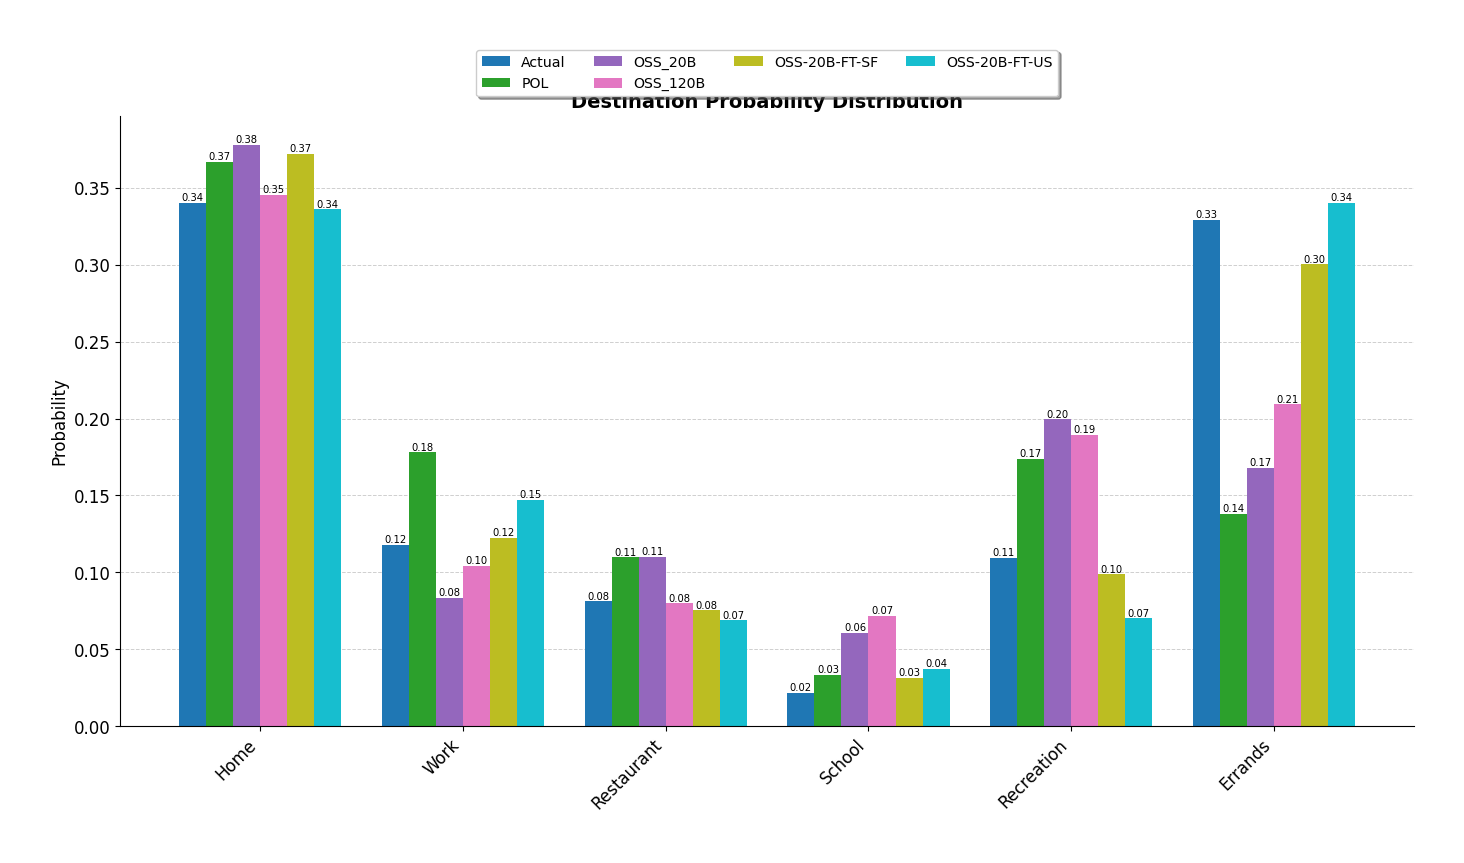

In [12]:
# Transition-probability comparison plot (destination distribution).
transition_data = {
    "Actual": get_transient_prob(actual_sf, list(STATE_CODES))
}
for model_name, model_df in model_frames.items():
    # if model_name == "POL":
    #     continue  # Skip POL for this plot since it's not directly comparable to actuals.
    transition_data[model_name] = get_transient_prob(model_df, list(STATE_CODES))

trip_level(transition_data, {k: LOC_TYPE_LABELS[k] for k in STATE_CODES}, font_size=12)


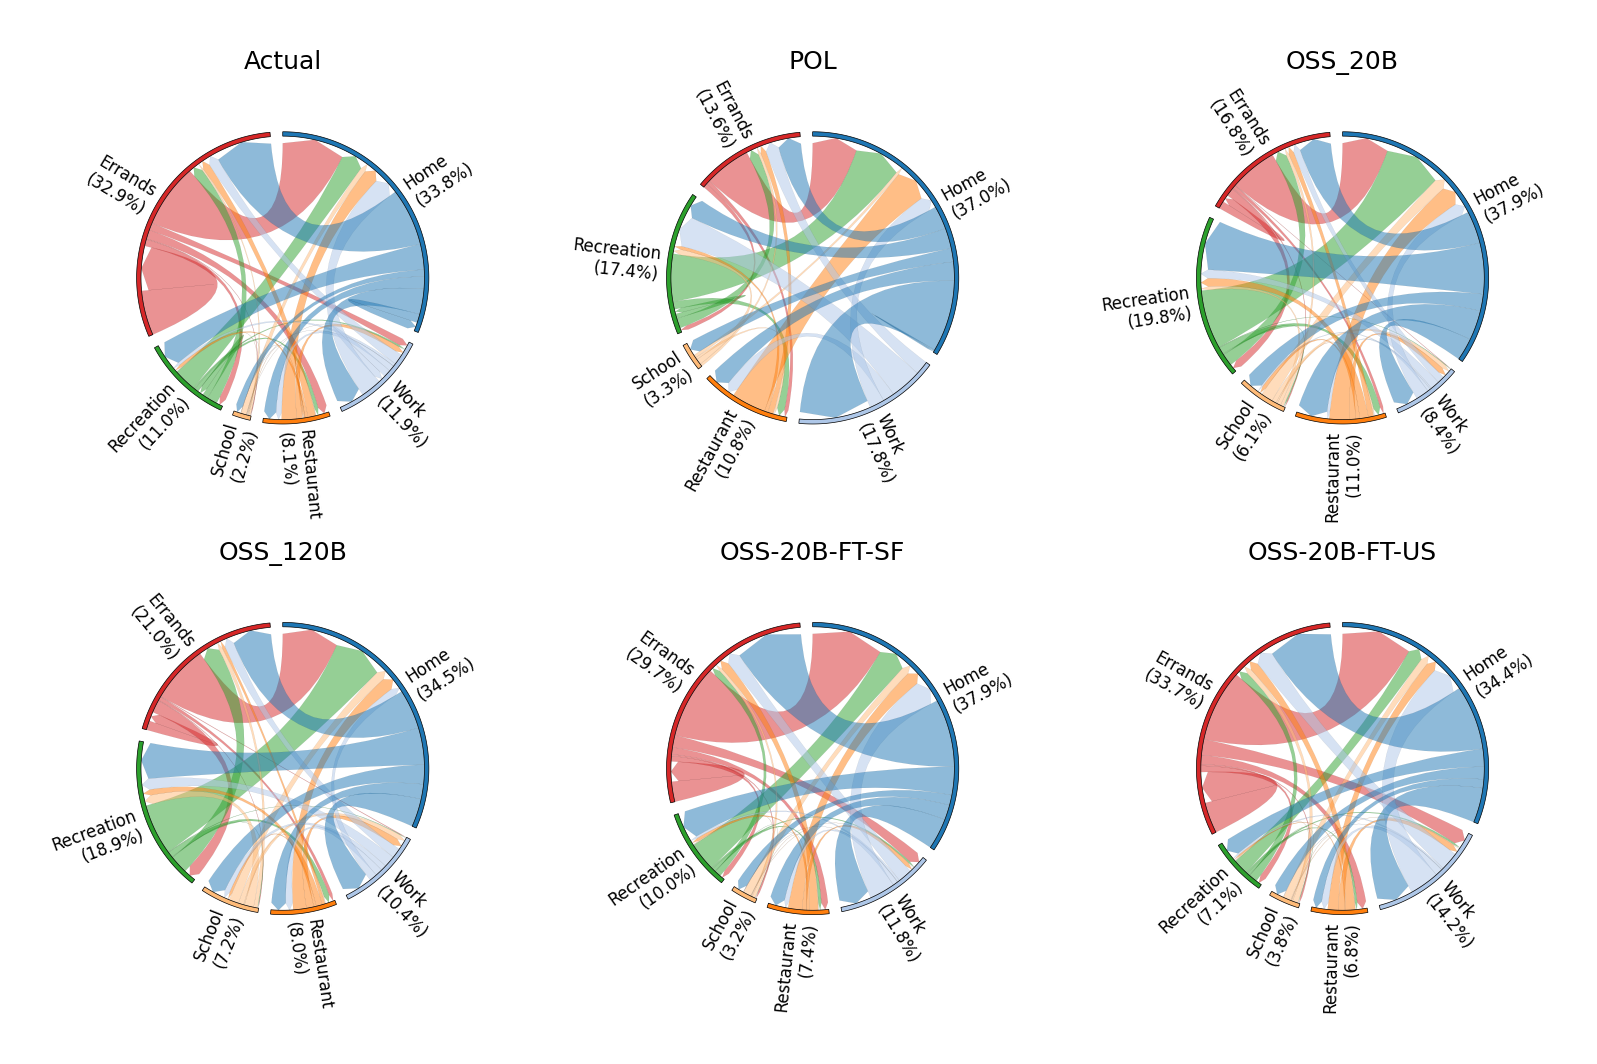

In [13]:
# Chain chord diagrams (visual inspection).
chain_plot_data = {"Actual": actual_sf, **model_frames}
# chain_plot_data.pop('POL', None)
# chain_plot_data.pop('Actual', None)
loc_dict = list(range(len(chain_plot_data)))
fig, axes = plot_chord_diagrams(chain_plot_data, loc_dict=loc_dict, figsize=(16, 10), loc_type_labels=LOC_TYPE_LABELS)


/Users/prb977/Project/MMv4/analysis/evals.py:1647: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.93])


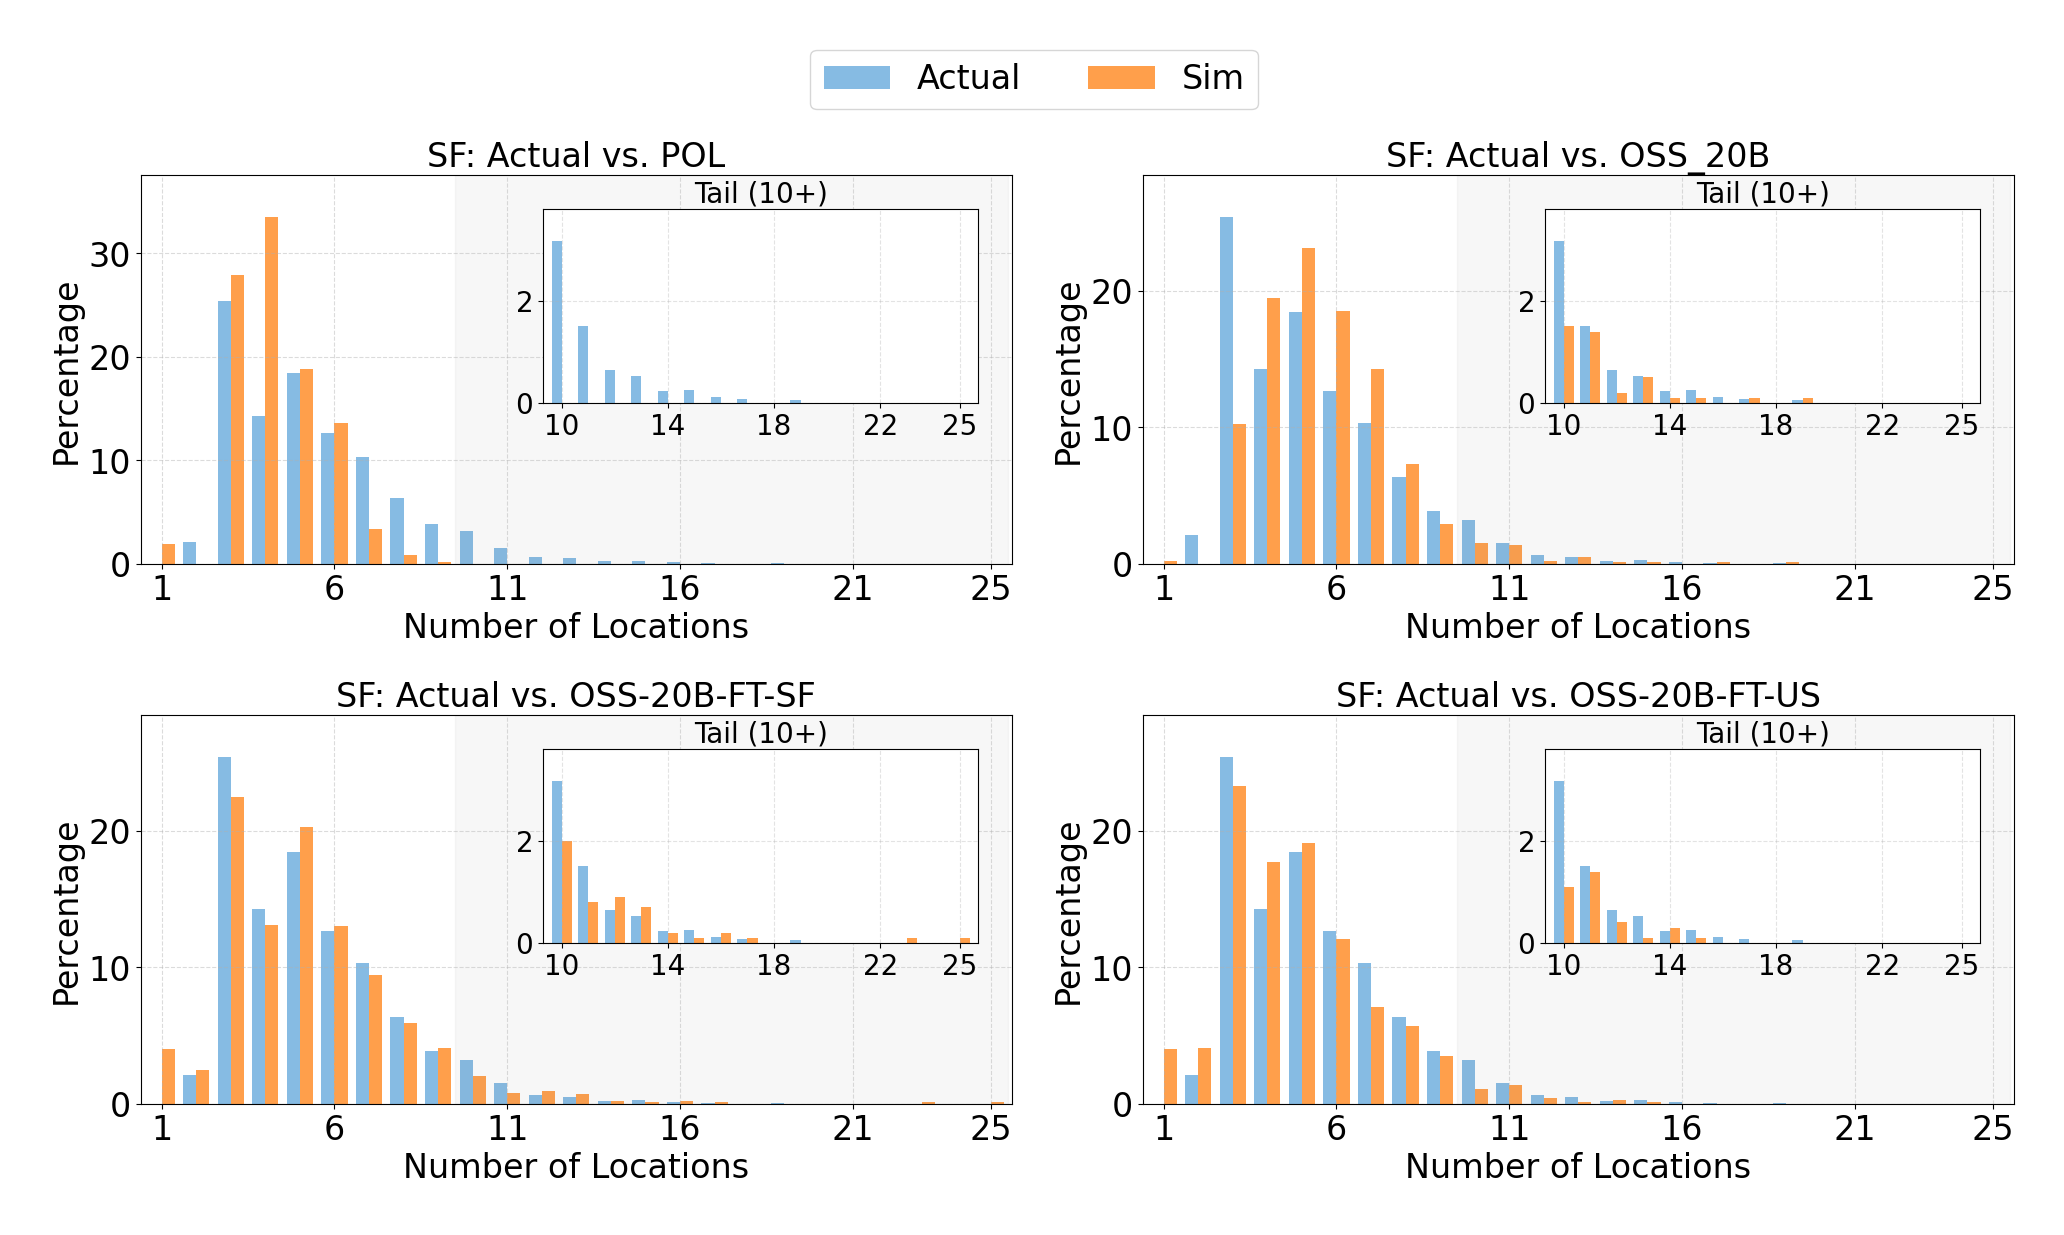

In [14]:
fig, axes = plot_location_count_percentage_grid_better(
    actual_counts=actual_loc_counts,
    # model_counts=model_loc_counts,
    model_counts={k: v for k,v in model_loc_counts.items() if k != "OSS_120B"},
    title_prefix='SF',
    font_size=24,
    tail_start=10,
    inset_width="50%",
    inset_height="50%",
    main_xtick_step=5,
    height_ratio=6,
    width_ratio=10.2,
    inset_xtick_step=4
)

# fig.savefig(
#     "/Users/prb977/Project/MMv4/_COLM_2026__Large_Scale_Urban_Simulation_with_LLMs/figures/location_count_percentage_grid.png",
#     dpi=300,
#     bbox_inches='tight'
# )

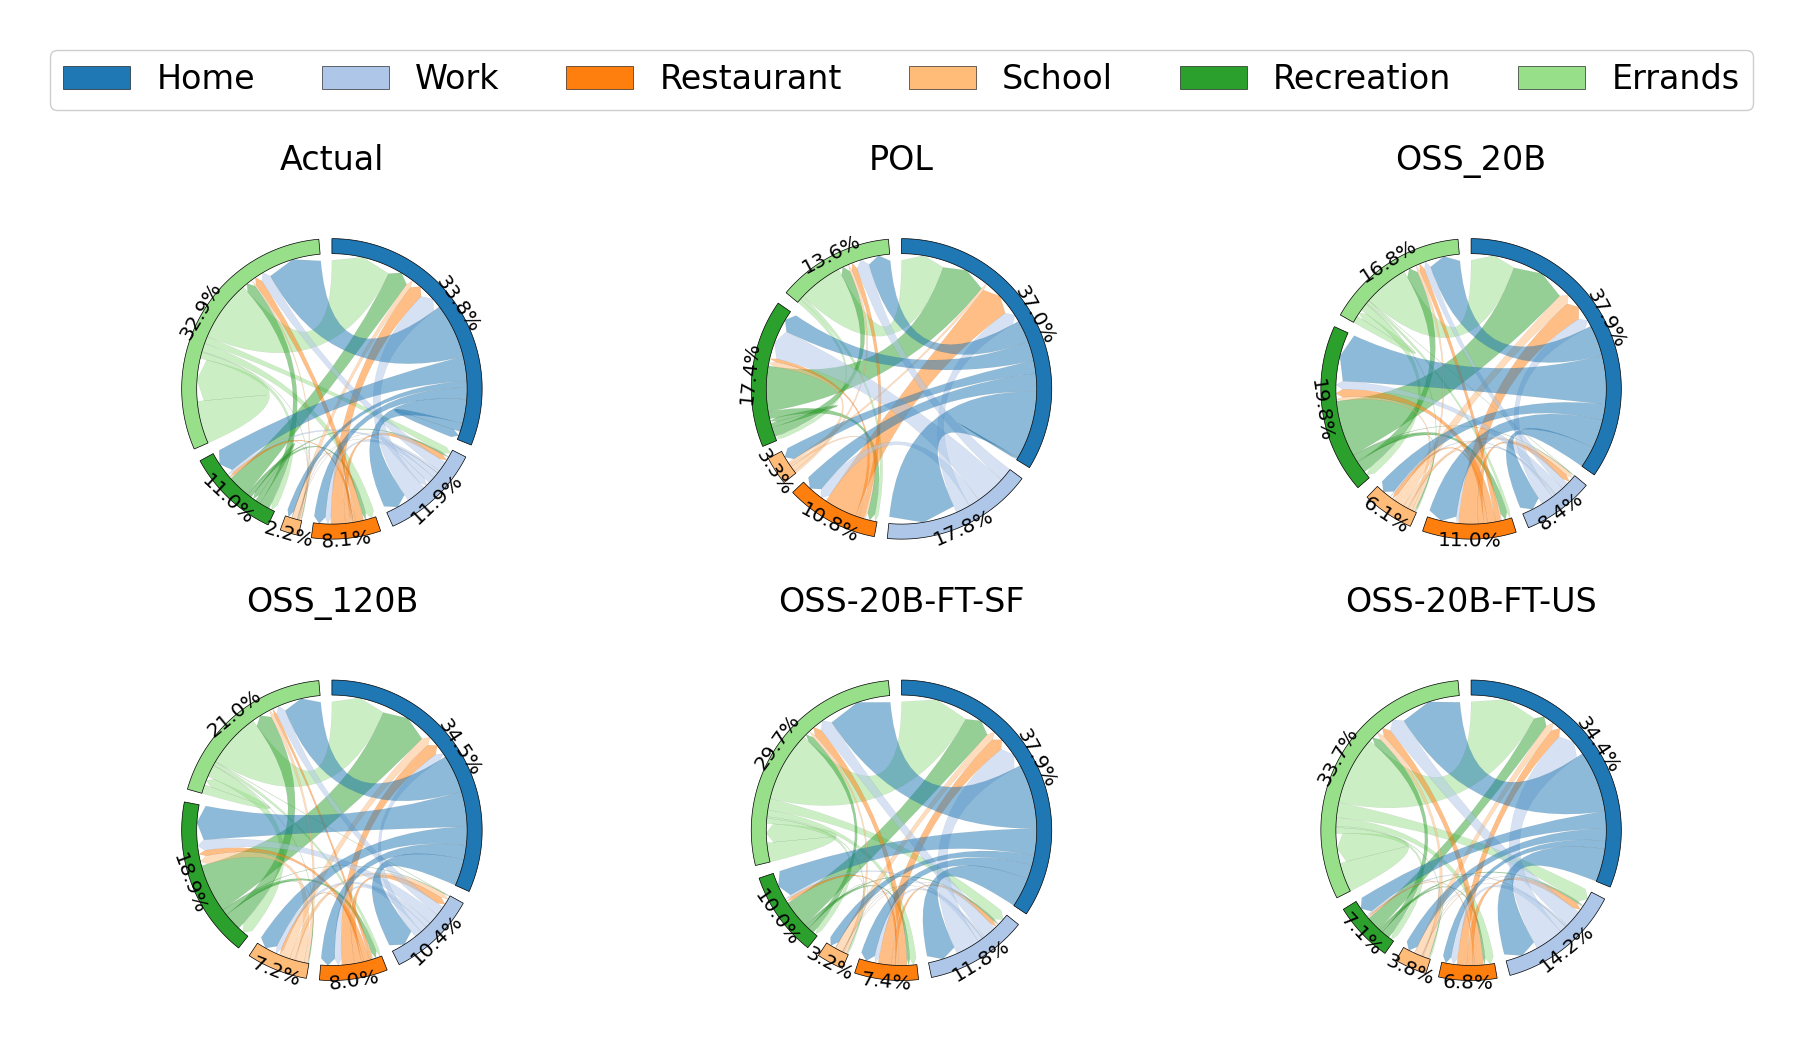

In [15]:
fig, axes, circos_objects = plot_chord_diagrams_better(
    chain_plot_data,
    loc_dict=loc_dict,
    figsize=(18, 10),
    loc_type_labels=LOC_TYPE_LABELS,
    font_size=24,
    ring_label_font_size_multiplier=0.6,   # <- new control
    label_mode="percent",
    label_position="inside",
    # min_pct_for_ring_label=4.5,            # try 4.0 or 4.5 for a cleaner look
    legend=True,
    legend_title=None,
    legend_ncol=6,                         # single boxed row like your histogram legend
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 0.995),
    r_lim=(90, 100),           # slightly thicker ring for labels
)
# fig.savefig("/Users/prb977/Project/MMv4/_COLM_2026__Large_Scale_Urban_Simulation_with_LLMs/figures/chord_diagram.png", dpi=300, bbox_inches='tight')